# Using other brain atlases with Nilearn

In this example, we see how to use other brain atlases in Nilearn, beyond those which are included in the atlas fetchers.

It is largely adapted from the following examples:

- [Using brain templates from TemplateFlow](https://nilearn.github.io/stable/auto_examples/01_plotting/plot_templateflow.html)
- [A short demo of the surface images & maskers](https://nilearn.github.io/stable/auto_examples/07_advanced/plot_surface_image_and_maskers.html#a-short-demo-of-the-surface-images-maskers)

## Accessing atlases from TemplateFlow

First, we see how to fetch and use brain templates
from [TemplateFlow](https://www.templateflow.org/).

TemplateFlow allows for the retrieval of image files, annotations, and
metadata for various brain templates.
Specific files are accessed via the ``get`` function
by providing the ``template`` name
and filtering by file name 'entities'
such as resolution (``res``),
``suffix``, ``atlas``, hemisphere (``hemi``), ``space``,
description (``desc``)...

  TemplateFlow files follow a [BIDS filename template](https://bids.neuroimaging.io/getting_started/folders_and_files/files.html#filename-template)
  and should more less be organized as [BIDS template](https://bids-specification.readthedocs.io/en/latest/derivatives/atlas.html).

If a search matches multiple files, the function returns a list of all matching paths.

Available resources can be explored in the
[TemplateFlow browser](https://www.templateflow.org/browse/).

## Fetch DK Surface template (surface example)

We can see how to fetch and use the [Desikan-Killiany (DK) atlas](https://surfer.nmr.mgh.harvard.edu/fswiki/CorticalParcellation) atlas in order to make surface plots.

In [1]:
import templateflow.api as tflow

from nilearn.surface import SurfaceImage, load_surf_data

template = "fsaverage"

fetched_files = tflow.get(
    template,
    extension="surf.gii",
    suffix="pial",
)
print(fetched_files)

[PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-3k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-10k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-41k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-L_den-164k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-3k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-10k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-41k_pial.surf.gii'), PosixPath('/home/jovyan/.cache/templateflow/tpl-fsaverage/tpl-fsaverage_hemi-R_den-164k_pial.surf.gii')]


In this example, the Desikan-Killiany (DK) atlas is fetched.
DK is defined with reference
to the *FreeSurfer average* (fsaverage) template,
which is provided at multiple densities (number of vertices per hemisphere):
3k, 10k, 41k, 164k
Here, we build a SurfaceImage containing the labels for both hemispheres
for the 3k and 10k densities.



In [2]:
used_densities = ["3k", "10k"]
# uncomment the following line in case you want to see all densities
# used_densities = ["3k", "10k", "41k", "164k"]

desikan_dict = {}
for density in ["3k", "10k"]:
    mesh = {}
    data = {}
    for hemi in ["left", "right"]:
        mesh[hemi] = tflow.get(
            template,
            extension="surf.gii",
            suffix="pial",
            density=density,
            hemi=hemi[0].upper(),
        )

        desc = "curated" if density == "164k" else None
        roi_data = load_surf_data(
            tflow.get(
                template,
                atlas="Desikan2006",
                density=density,
                hemi=hemi[0].upper(),
                extension="label.gii",
                desc=desc,
            )
        )
        if density == "164k":
            roi_data[roi_data < 0] = 0

        data[hemi] = roi_data

    desikan_dict[density] = SurfaceImage(mesh=mesh, data=data)

## Plotting the DK atlas (surface example)
To plot the DK atlas, we also fetch the lookup table (LUT) from TemplateFlow,
to map region indices to the original region names and colors.
We also use the background sulcal depth map
to add more detail to the surface plot.
To do this we map the density
to the corresponding fsaverage data that Nilearn can fetch directly.



[load_fsaverage_data] Dataset found in /home/jovyan/nilearn_data/fsaverage4

[load_fsaverage_data] Dataset found in /home/jovyan/nilearn_data/fsaverage4

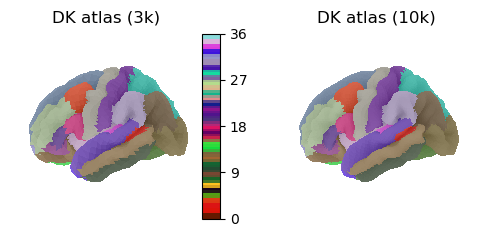

In [3]:
import matplotlib.pyplot as plt

import pandas as pd
from nilearn.datasets import load_fsaverage_data
from nilearn.plotting import plot_surf_roi, show

_, axes = plt.subplots(1, 2, subplot_kw={"projection": "3d"})

fs_density = {
    "3k": "fsaverage4",
    "10k": "fsaverage5",
    "41k": "fsaverage6",
    "164k": "fsaverage",
}

lut_file = tflow.get(
    template,
    atlas="Desikan2006",
    suffix="dseg",
    extension="tsv",
)
lut = pd.read_csv(lut_file, sep="\t")

for ax, density in zip(axes, ["3k", "10k"], strict=True):
    desikan = desikan_dict[density]
    sulcal_depth_map = load_fsaverage_data(
        mesh=fs_density[density], data_type="sulcal"
    )
    plot_surf_roi(
        roi_map=desikan,
        cmap=lut,
        bg_map=sulcal_depth_map,
        bg_on_data=True,
        title=f"DK atlas ({density})",
        axes=ax,
    )
    if density == "10k":
        ax._colorbars[0].remove()

show()

## Getting the right template for Harvard-Oxford atlas (volume example)
The template used by nilearn to plot volumetric images is ICBM152 2009,
release a.
However, some atlases are defined on different templates,
this is the case for the Harvard-Oxford atlas.
This can lead to some imprecisions
when plotting volumetric atlases, with regions encompassing non-brain areas.


[fetch_atlas_harvard_oxford] Dataset found in /home/jovyan/nilearn_data/fsl

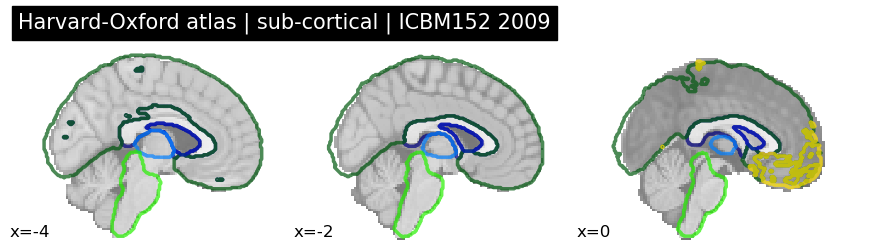

In [4]:
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.plotting import plot_roi

plotting_params = {
    "view_type": "contours",
    "display_mode": "x",
    "cut_coords": [-4, -2, 0],
    "black_bg": False,
}

harvard_oxford_sub = fetch_atlas_harvard_oxford("sub-maxprob-thr25-1mm")


plot_roi(
    harvard_oxford_sub.filename,
    title="Harvard-Oxford atlas | sub-cortical | ICBM152 2009",
    **plotting_params,
)

This is because the template of the Harvard-Oxford atlas is:



In [5]:
print(f"Harvard-Oxford atlas template: {harvard_oxford_sub.template}")

Harvard-Oxford atlas template: MNI152NLin6Asym


### Getting the right template for our atlas
Let's visualize the Harvard-Oxford atlas on the template it was originally defined,
which we can get from TemplateFlow. 

This template is the default template used by FSL, and its unique identifier within TemplateFlow
is`MNI152NLin6Asym`.



MNI152NLin6Asym_template_img=PosixPath('/home/jovyan/.cache/templateflow/tpl-MNI152NLin6Asym/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz')


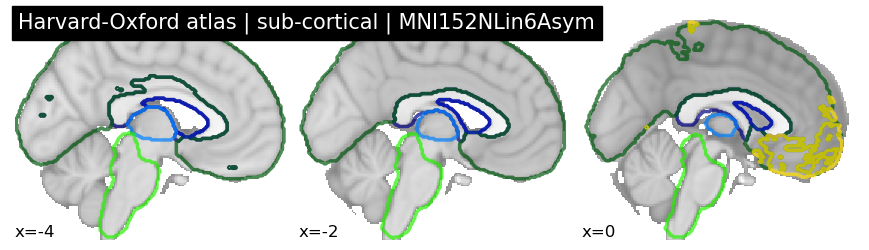

In [6]:
template = "MNI152NLin6Asym"
resolution = "01"

MNI152NLin6Asym_template_img = tflow.get(
    template,
    resolution=resolution,
    suffix="T1w",
    desc="brain",  # Set desc-brain to get the skull-stripped variant
    extension="nii.gz",
)

print(f"{MNI152NLin6Asym_template_img=}")

plot_roi(
    harvard_oxford_sub.filename,
    title="Harvard-Oxford atlas | sub-cortical | MNI152NLin6Asym",
    bg_img=MNI152NLin6Asym_template_img,
    **plotting_params,
)

show()

## Comparing the same atlas on different templates (volume example)

Note that we can also get the same atlas on different templates.
In this case, we plot both on the default Nilearn background image (`bg_img`) which is ICBM152 2009, release a. 

We can see that each atlas (in the different template spaces) has slightly differing mismatches with the ICMBM template.

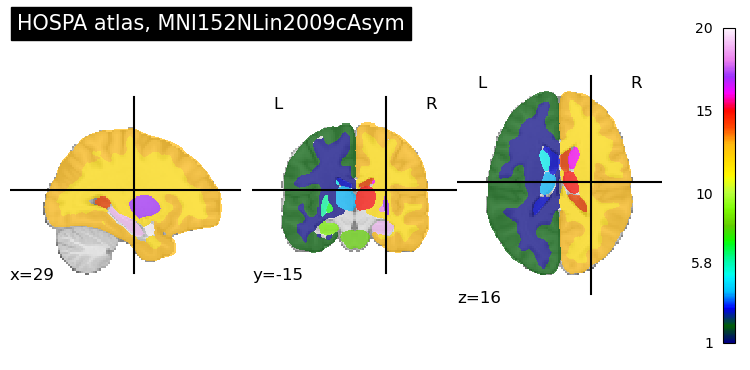

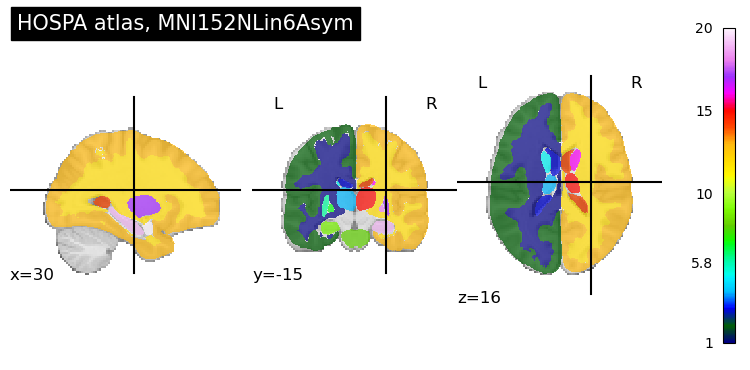

In [7]:
from nilearn import plotting

templates = ["MNI152NLin2009cAsym", "MNI152NLin6Asym"]

for tpl in templates:
    atlas_fname = tflow.get(
        tpl,
        atlas="HOSPA",
        suffix="dseg",
        resolution=1,
        desc="th50"
    )
    plotting.plot_roi(
        atlas_fname,
        title=f'HOSPA atlas, {tpl}',
        display_mode='ortho',
        draw_cross=True,
        # bg_img=None,
        colorbar=True,
    )

## Working with an atlas outside of TemplateFlow (surface example)

Finally, we will show how to integrate a custom atlas with Nilearn masker objects.
In this case, we will use the HCP Glasser parcellation, which is not distributed with `templateflow` due to HCP terms.
For this, we will use the `hcp_utils` library.

Note that this section is largely adapted from [the Connectivity with a Surface Atlas and Surface Labels Masker](https://nilearn.github.io/stable/auto_examples/07_advanced/plot_surface_image_and_maskers.html#connectivity-with-a-surface-atlas-and-surfacelabelsmasker).

In [8]:
import hcp_utils as hcp
from nilearn.surface import InMemoryMesh, PolyMesh

# define the mesh for the left and right hemispheres
left_coords, left_faces = hcp.mesh["pial_left"]
right_coords, right_faces = hcp.mesh["pial_right"]

mesh = PolyMesh(
    left=InMemoryMesh(left_coords, left_faces),
    right=InMemoryMesh(right_coords, right_faces),
)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [9]:
from nilearn.surface import SurfaceImage

# we use the Multi Modal Parcellation (MMP) provided in hcp_utils
# https://rmldj.github.io/hcp-utils/parcellation_labels.html
parc = hcp.mmp
right_data = hcp.right_cortex_data(parc.map_all)
left_data = hcp.left_cortex_data(parc.map_all)

data = {
    "left": left_data,
    "right": right_data,
}

labels_image = SurfaceImage(mesh=mesh, data=data)

In [10]:
import pandas as pd

# we define a BIDS-formatted Look Up Table (LUT)
# this will follow the structure shown here :
# https://bids-specification.readthedocs.io/en/stable/derivatives/imaging.html#atlas-tabular-data 

lut = pd.DataFrame(parc.labels.values(), index=parc.labels.keys(), columns=["name"])
lut.iloc[0] = "Background"
lut['color'] = parc.rgba.values()
lut['index'] = lut.index
lut.head()

,name,color,index
0,Background,"[0.0, 0.0, 0.0, 0.0]",0
1,L_V1,"[0.262745, 0.0392157, 1.0, 1.0]",1
2,L_MST,"[0.192157, 0.356863, 0.498039, 1.0]",2
3,L_V6,"[0.192157, 0.333333, 0.658824, 1.0]",3
4,L_V2,"[0.0509804, 0.2, 0.929412, 1.0]",4


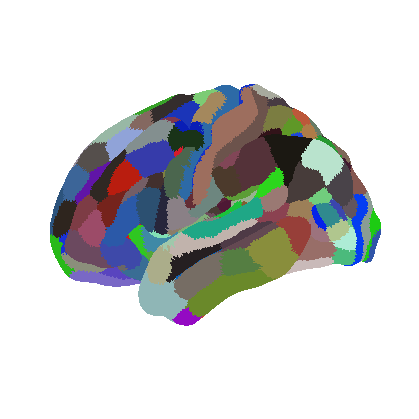

In [11]:
from nilearn.plotting import plot_surf_roi, show

plot_surf_roi(surf_mesh=mesh, roi_map=labels_image, cmap=lut, colorbar=False)
show()

In [12]:
from nilearn.maskers import SurfaceLabelsMasker

surface_lbls_masker = SurfaceLabelsMasker(labels_img=labels_image, lut=lut)
report = surface_lbls_masker.fit()
report

,labels_img,"<SurfaceImage (64984,)>"
,labels,None
,lut,...s x 3 columns]
,background_label,0
,mask_img,None
,smoothing_fwhm,None
,standardize,False
,standardize_confounds,True
,detrend,False
,high_variance_confounds,False
,low_pass,None
